# Procesamiento de Lenguaje Natural
## Modelo de lenguaje con tokenización por caracteres

>  SimpleRNN, LSTM y GRU con rmsprop
>

In [1]:
# Celda 0 - Instalacion
!pip install lxml -q
print('Dependencias instaladas')

Dependencias instaladas


In [2]:
# Celda 1 - Importaciones
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import bs4 as bs

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, GRU, SimpleRNN, LSTM, TimeDistributed, CategoryEncoding
from tensorflow.keras.utils import pad_sequences
from scipy.special import softmax

import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU disponible:', gpus)
else:
    print('GPU no detectada. Configurar GPU')

2026-06-03 23:28:37.853945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780529318.093797      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780529318.161542      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780529318.707787      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780529318.707834      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780529318.707837      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Celda 2 - Parametros
URL_CORPUS       = 'https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook'
MAX_CONTEXT_SIZE = 100
P_VAL            = 0.1
STEP             = 5
UNITS            = 128
BATCH_SIZE       = 512
EPOCHS           = 30
PATIENCE         = 30
SEED_TEXT        = 'el senor fogg'
N_CHARS          = 150
MODEL_PATH       = '/kaggle/working/best_model_desafio3.keras'

print('Parametros configurados')
print('UNITS:', UNITS, '| STEP:', STEP, '| EPOCHS:', EPOCHS, '| PATIENCE:', PATIENCE)

Parametros configurados
UNITS: 128 | STEP: 5 | EPOCHS: 30 | PATIENCE: 30


In [4]:
# Celda 3 - Corpus y tokenizacion por caracteres
print('Descargando corpus...')
raw_html     = urllib.request.urlopen(URL_CORPUS).read()
soup         = bs.BeautifulSoup(raw_html, 'lxml')
article_text = ' '.join(p.text for p in soup.find_all('p')).lower()
print('Corpus:', len(article_text), 'caracteres')

# sorted() garantiza siempre el mismo orden del vocabulario
chars_vocab = sorted(set(article_text))
vocab_size  = len(chars_vocab)
char2idx    = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char    = {idx: ch for ch, idx in char2idx.items()}
print('Vocabulario:', vocab_size, 'caracteres unicos')

tokenized_text = [char2idx[ch] for ch in article_text]
print('Texto tokenizado:', len(tokenized_text), 'tokens')

Descargando corpus...
Corpus: 395528 caracteres
Vocabulario: 67 caracteres unicos
Texto tokenizado: 395528 tokens


In [5]:
# Celda 4 - Dataset train/validacion
num_val    = int(np.ceil(len(tokenized_text) * P_VAL / MAX_CONTEXT_SIZE))
train_text = tokenized_text[:-num_val * MAX_CONTEXT_SIZE]
val_text   = tokenized_text[-num_val * MAX_CONTEXT_SIZE:]

# Validacion: ultimo 10% del corpus
tokenized_sentences_val = [
    val_text[i * MAX_CONTEXT_SIZE : (i + 1) * MAX_CONTEXT_SIZE]
    for i in range(num_val)
]

# Entrenamiento: ventana deslizante con paso STEP
tokenized_sentences_train = [
    train_text[i : i + MAX_CONTEXT_SIZE]
    for i in range(0, len(train_text) - MAX_CONTEXT_SIZE + 1, STEP)
]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

print('Tokens entrenamiento:', len(train_text))
print('Tokens validacion:', len(val_text))
print('Secuencias entrenamiento:', X.shape[0])
print('Secuencias validacion:', num_val)
print('Shape X:', X.shape, '| Shape y:', y.shape)

Tokens entrenamiento: 355928
Tokens validacion: 39600
Secuencias entrenamiento: 71165
Secuencias validacion: 396
Shape X: (71165, 100) | Shape y: (71165, 100)


In [ ]:
# Celda 5 - Callback de Perplejidad
# Early stopping: detiene si no mejora en PATIENCE epocas consecutivas

class PplCallback(keras.callbacks.Callback):

    def __init__(self, val_data, history_ppl, patience=5):
        self.val_data         = val_data
        self.history_ppl      = history_ppl
        self.target           = []
        self.padded           = []
        self.info             = []
        self.min_score        = np.inf
        self.patience_counter = 0
        self.patience         = patience
        count = 0

        for seq in self.val_data:
            len_seq = len(seq)
            subseq  = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if len(subseq) != 0:
                self.padded.append(
                    pad_sequences(subseq, maxlen=MAX_CONTEXT_SIZE, padding='pre')
                )
                self.info.append((count, count + len_seq))
                count += len_seq

        self.padded = np.vstack(self.padded)
        print('Callback:', self.padded.shape[0], 'subsecuencias pre-computadas')

    def on_epoch_end(self, epoch, logs=None):
        scores      = []
        predictions = self.model.predict(self.padded, batch_size=1024, verbose=0)

        for start, end in self.info:
            probs = [
                predictions[idx_seq, -1, idx_vocab]
                for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])
            ]
            scores.append(
                np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / (end - start))
            )

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print('\n  Perplejidad validacion:', round(current_score, 4))

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(MODEL_PATH)
            print('  -> Mejor modelo guardado.')
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print('  -> Early stopping activado.')
                self.model.stop_training = True

print('Callback definido.')

Callback definido.


In [7]:
# Celda 6 - Arquitecturas: SimpleRNN, LSTM y GRU con rmsprop
# rmsprop es el optimizador recomendado para RNNs

def build_model_simplernn(vocab_size, units=128):
    model = Sequential([
        TimeDistributed(
            CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
            input_shape=(None, 1)
        ),
        SimpleRNN(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

def build_model_lstm(vocab_size, units=128):
    model = Sequential([
        TimeDistributed(
            CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
            input_shape=(None, 1)
        ),
        LSTM(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

def build_model_gru(vocab_size, units=128):
    model = Sequential([
        TimeDistributed(
            CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
            input_shape=(None, 1)
        ),
        GRU(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

print('Arquitecturas definidas con rmsprop.')

Arquitecturas definidas con rmsprop.


In [8]:
# Celda 7 - Entrenamiento de los 3 modelos

historiales_ppl = {}
modelos = {
    'SimpleRNN': build_model_simplernn(vocab_size, UNITS),
    'LSTM':      build_model_lstm(vocab_size, UNITS),
    'GRU':       build_model_gru(vocab_size, UNITS),
}

for nombre, modelo in modelos.items():
    print('\n' + '='*50)
    print('Entrenando', nombre, '...')
    print('='*50)
    history_ppl = []
    historiales_ppl[nombre] = history_ppl
    modelo.fit(
        X, y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[PplCallback(tokenized_sentences_val, history_ppl, PATIENCE)]
    )

print('\nEntrenamiento finalizado.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1780529337.356479      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780529337.362673      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Entrenando SimpleRNN ...
Callback: 39204 subsecuencias pre-computadas
Epoch 1/30


I0000 00:00:1780529344.019366     135 service.cc:152] XLA service 0x28693100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780529344.019417     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780529344.019421     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780529344.580342     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/139 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 4.0319

I0000 00:00:1780529347.675742     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.2054
  Perplejidad validacion: 20.7517
  -> Mejor modelo guardado.
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - loss: 3.0703
Epoch 2/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.0134
  Perplejidad validacion: 20.7288
  -> Mejor modelo guardado.
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.0121
Epoch 3/30
137/139 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0082
  Perplejidad validacion: 20.7585
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.0070
Epoch 4/30
137/139 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0045
  Perplejidad validacion: 20.8821
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 3.0037
Epoch 5/30
137/139 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0015
  Perplejidad validacion: 20.9696
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 3.0007
Epoch 6/30
137/139 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.9985
  Perplejidad validacion: 21.2781
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 2.9974

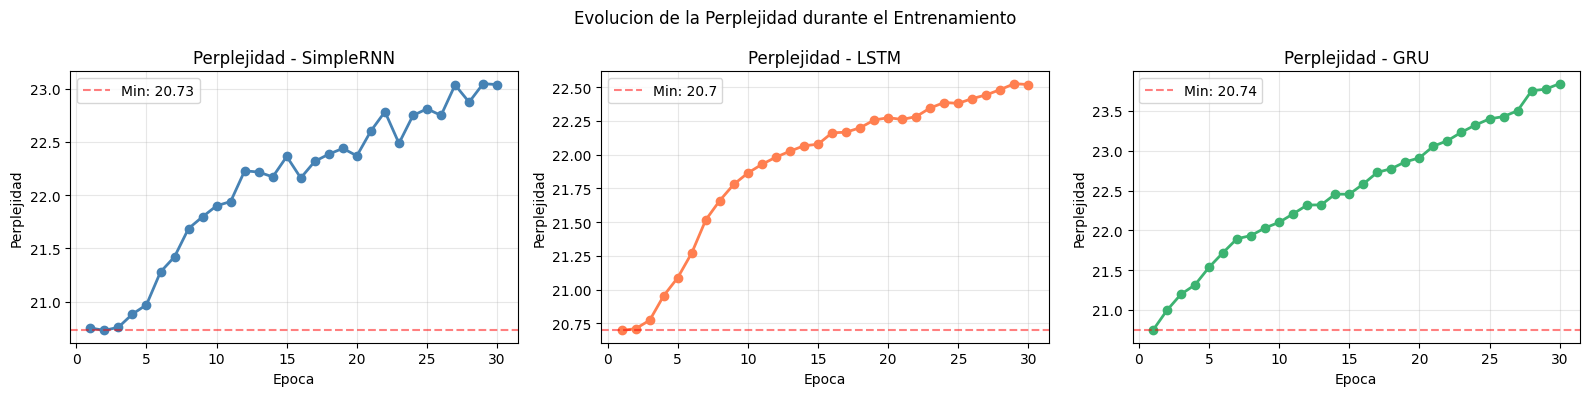


Resumen de perplejidades minimas:
  SimpleRNN : 20.7288 (epoca 2 )
  LSTM : 20.6979 (epoca 1 )
  GRU : 20.7419 (epoca 1 )


In [9]:
# Celda 8 - Comparacion de perplejidad
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colores = {'SimpleRNN': 'steelblue', 'LSTM': 'coral', 'GRU': 'mediumseagreen'}

for ax, (nombre, hist) in zip(axes, historiales_ppl.items()):
    epocas = range(1, len(hist)+1)
    ax.plot(epocas, hist, color=colores[nombre], linewidth=2, marker='o')
    ax.set_title('Perplejidad - ' + nombre)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Perplejidad')
    ax.grid(True, alpha=0.3)
    if hist:
        ax.axhline(min(hist), color='red', linestyle='--', alpha=0.5,
                   label='Min: ' + str(round(min(hist), 2)))
        ax.legend()

plt.suptitle('Evolucion de la Perplejidad durante el Entrenamiento')
plt.tight_layout()
plt.show()

print('\nResumen de perplejidades minimas:')
for nombre, hist in historiales_ppl.items():
    if hist:
        print(' ', nombre, ':', round(min(hist), 4), '(epoca', int(np.argmin(hist))+1, ')')

In [10]:
# Celda 9 - Cargar mejor modelo
best_model = keras.models.load_model(MODEL_PATH)
print('Mejor modelo cargado:', MODEL_PATH)
best_model.summary()

Mejor modelo cargado: /kaggle/working/best_model_desafio3.keras


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 128)      │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 67)       │         8,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,584 (658.54 KB)

 Trainable params: 84,291 (329.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84,293 (329.27 KB)

In [11]:
# Celda 10 - Funciones auxiliares encode/decode
def encode(text, max_length=MAX_CONTEXT_SIZE):
    encoded = [char2idx[ch] for ch in text.lower() if ch in char2idx]
    return pad_sequences([encoded], maxlen=max_length, padding='pre')

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq if ch in idx2char])

print('Funciones encode/decode definidas.')
print('Test encode:', SEED_TEXT, '->', encode(SEED_TEXT).shape)

Funciones encode/decode definidas.
Test encode: el senor fogg -> (1, 100)


In [12]:
# Celda 11 - Greedy Search
# Elige el caracter con mayor probabilidad en cada paso (argmax)
# Deterministico pero tiende a loops repetitivos

def greedy_search(model, seed_text, n_chars):
    output_text = seed_text
    for _ in range(n_chars):
        probs = model.predict(encode(output_text), verbose=0)[0, -1, :]
        output_text += idx2char[np.argmax(probs)]
    return output_text

seeds = ['el senor fogg', 'la vuelta al', 'en aquel momento']
print('='*60)
print('GREEDY SEARCH')
print('='*60)
for seed in seeds:
    print('\nSeed:', seed)
    print('->', greedy_search(best_model, seed, N_CHARS))

GREEDY SEARCH

Seed: el senor fogg
-> el senor fogg  a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 

Seed: la vuelta al
-> la vuelta al a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a

Seed: en aquel momento
-> en aquel momento  a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 


In [13]:
# Celda 12 - Top-k Sampling: solucion al loop
# Paso 1: toma los k caracteres mas probables
# Paso 2: aplica temperatura para ajustar la distribucion
# Paso 3: muestrea aleatoriamente entre los k candidatos

def top_k_sampling(model, seed_text, n_chars, k=5, temp=0.7):
    output_text = seed_text
    for _ in range(n_chars):
        probs       = model.predict(encode(output_text), verbose=0)[0, -1, :]
        top_k_idx   = np.argsort(probs)[::-1][:k]
        top_k_probs = softmax(np.log(probs[top_k_idx] + 1e-10) / temp)
        output_text += idx2char[np.random.choice(top_k_idx, p=top_k_probs)]
    return output_text

seeds   = ['el senor fogg', 'la vuelta al', 'en aquel momento']
configs = [
    {'k': 3,  'temp': 0.7, 'label': 'k=3  T=0.7 conservador'},
    {'k': 5,  'temp': 0.7, 'label': 'k=5  T=0.7 recomendado'},
    {'k': 10, 'temp': 1.0, 'label': 'k=10 T=1.0 mas variado'},
]

for seed in seeds:
    print('\n' + '='*60)
    print('Seed:', seed)
    print('='*60)
    for cfg in configs:
        np.random.seed(42)
        resultado = top_k_sampling(best_model, seed, N_CHARS, k=cfg['k'], temp=cfg['temp'])
        print('\n  [' + cfg['label'] + ']')
        print('  ->', resultado)


Seed: el senor fogg

  [k=3  T=0.7 conservador]
  -> el senor fogg eaa  aeaa ee a aa   a a e   aa aeee aa   ae  aaa eeeeae  a a e aa e ee aeaae  aea  a   ea    eaa  a  aae   a a eeaee eaee a  ee   a ae   aee  a aaa  

  [k=5  T=0.7 recomendado]
  -> el senor fogg nee a oee no  a   ae    o  e e anno  ea  an e   anenoan  a  ao   ao no  oeee  aoe a  eeoa eeaeaaa  ae  n  o a anoeoo oaoo  aaoo aa   r  eann   a ea a

  [k=10 T=1.0 mas variado]
  -> el senor foggednn a isr di a  oean  eei os r addra re o lanaoo drdlnl  aaearaao s dr  snsr e isa aassia rroreoe  anaolaei   alrnri iorda aeii oea alaonaddaeaa no a

Seed: la vuelta al

  [k=3  T=0.7 conservador]
  -> la vuelta al eaa  aeaa ee a aa   a a e   aa aeee aa   ae  aaa eeeeae  a a e aa e ee aeaae  aea  a   ea    eaa  a  aae   a a eeaee eaee a  ee   a ae   aee  a aaa  

  [k=5  T=0.7 recomendado]
  -> la vuelta alanea  aoae no  a   ae    o  e e anno  ea  an e   anenoan  a  ao   ao no  oeee  aoe a  eeoa eeaeaaa  ae  n  o a anoeoo oaoo  aao

In [14]:
def nucleus_sampling(model, seed_text, n_chars, p=0.9, temp=0.7):
    """
    Nucleus (top-p) sampling: en cada paso toma los tokens que
    acumulan probabilidad >= p y muestrea entre ellos.
    A diferencia de top-k, el tamaño del conjunto varia segun
    la distribucion — si el modelo esta seguro usa pocos tokens,
    si esta inseguro usa mas.
    """
    output_text = seed_text
    for _ in range(n_chars):
        probs = model.predict(encode(output_text), verbose=0)[0, -1, :]

        # Ordenar de mayor a menor probabilidad
        sorted_idx   = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_idx]

        # Acumular hasta llegar a p
        cumulative = np.cumsum(sorted_probs)
        cutoff     = np.searchsorted(cumulative, p) + 1

        # Quedarse solo con los tokens del nucleo
        nucleus_idx   = sorted_idx[:cutoff]
        nucleus_probs = sorted_probs[:cutoff]

        # Aplicar temperatura y renormalizar
        nucleus_probs = softmax(np.log(nucleus_probs + 1e-10) / temp)

        # Muestrear
        output_text += idx2char[np.random.choice(nucleus_idx, p=nucleus_probs)]

    return output_text


# Probar
seeds = ['el senor fogg', 'la vuelta al', 'en aquel momento']
for seed in seeds:
    np.random.seed(42)
    print('Seed:', seed)
    print('->', nucleus_sampling(best_model, seed, N_CHARS, p=0.9, temp=0.7))
    print()

Seed: el senor fogg
-> el senor foggaprn  adsr ml    oean  eer os r aumi  se o uasaeo miutoc a  ealaao l ,i  lrri e dna aarsta sioiaee  anaecaer   aursti toite aeld oe aauaenamp oaa no a

Seed: la vuelta al
-> la vuelta aleprn  adsr ml    oean  eer os r aumi  se o uasaeo miutoc a  ealaao l ,i  lrri e dna aarsta sioiaee  anaecaer   aursti toite aeld oe aauaenamp oaa no a

Seed: en aquel momento
-> en aquel momentoaprn  adsr ml    oean  eer os r aumi  se o uasaeo miutoc a  ealaao l ,i  lrri e dna aarsta sioiaee  anaecaer   aursti toite aeld oe aauaenamp oaa no a



In [15]:
# Celda 13 - Beam Search funciones

def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]), num_beams, replace=False,
            p=softmax(pred_large / temp)
        )

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T), axis=1
    )
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input_text, temp=1.0, mode='det'):
    encoded        = encode(input_text)
    y_hat          = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size     = y_hat.shape[0]
    history_probs  = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )
    for i in range(num_words - 1):
        preds = [model.predict(np.array([hist[i+1:]]), verbose=0)[0, -1, :]
                 for hist in history_tokens]
        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )
    return history_tokens[:, -(len(input_text) + num_words):]

print('Funciones Beam Search definidas.')

Funciones Beam Search definidas.


In [16]:
# Celda 14 - Beam Search deterministico
print('='*60)
print('BEAM SEARCH DETERMINISTICO  (num_beams=5)')
print('='*60)
salidas_det = beam_search(best_model, num_beams=5, num_words=100,
                          input_text=SEED_TEXT, mode='det')
print('Seed:', SEED_TEXT)
print()
for i, beam in enumerate(salidas_det):
    print('Beam', i+1, ':', decode(beam))

BEAM SEARCH DETERMINISTICO  (num_beams=5)
Seed: el senor fogg

Beam 1 : el senor fogg a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Beam 2 : el senor fogg  a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 
Beam 3 : el senor fogg a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a  
Beam 4 : el senor fogg a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a  a 
Beam 5 : el senor fogg a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a  a a 


In [17]:
# Celda 15 - Beam Search estocastico y efecto de la temperatura
# T < 1 -> distribucion concentrada -> texto predecible
# T = 1 -> distribucion original del modelo
# T > 1 -> distribucion plana -> texto mas creativo

temperatures = [0.3, 0.7, 1.0, 1.5, 2.0]
print('='*60)
print('BEAM SEARCH ESTOCASTICO - Efecto de la Temperatura')
print('='*60)
print('Seed:', SEED_TEXT)
print()
for temp in temperatures:
    np.random.seed(42)
    salidas = beam_search(best_model, num_beams=3, num_words=100,
                          input_text=SEED_TEXT, temp=temp, mode='sto')
    print('T =', temp, ': ', decode(salidas[0]))
    print()

BEAM SEARCH ESTOCASTICO - Efecto de la Temperatura
Seed: el senor fogg

T = 0.3 :  el senor fogg aaa a a  a  a a aa     a  a  a  a a  a a a a  a a aa a a a a a a a a   i  a a a a a  a r  a a aa  a

T = 0.7 :  el senor foggaa t  aaa   la eae ae  dea e n en  eea a  a  e  aa eo  a  s ia rd lea  eta sr se s aieo ae o o s a t

T = 1.0 :  el senor foggdle e eee  g  a toero  
n n ieep at lnuo  aaraa asod mae easd oncseaees anancooraesa s scc ec ne sne

T = 1.5 :  el senor fogge p ee oe ajdarns ep aammef  da gabiseí d aborsersemu d  edamdansiueaeou.usda—b dt r rbldreuo m,seie

T = 2.0 :  el senor fogge,n ltnmntui are¿,a,sceeuscaoa    tureoc preatt.,tadbaae ree nca—od l¡ucuepcld
t neih recseaspa oghe



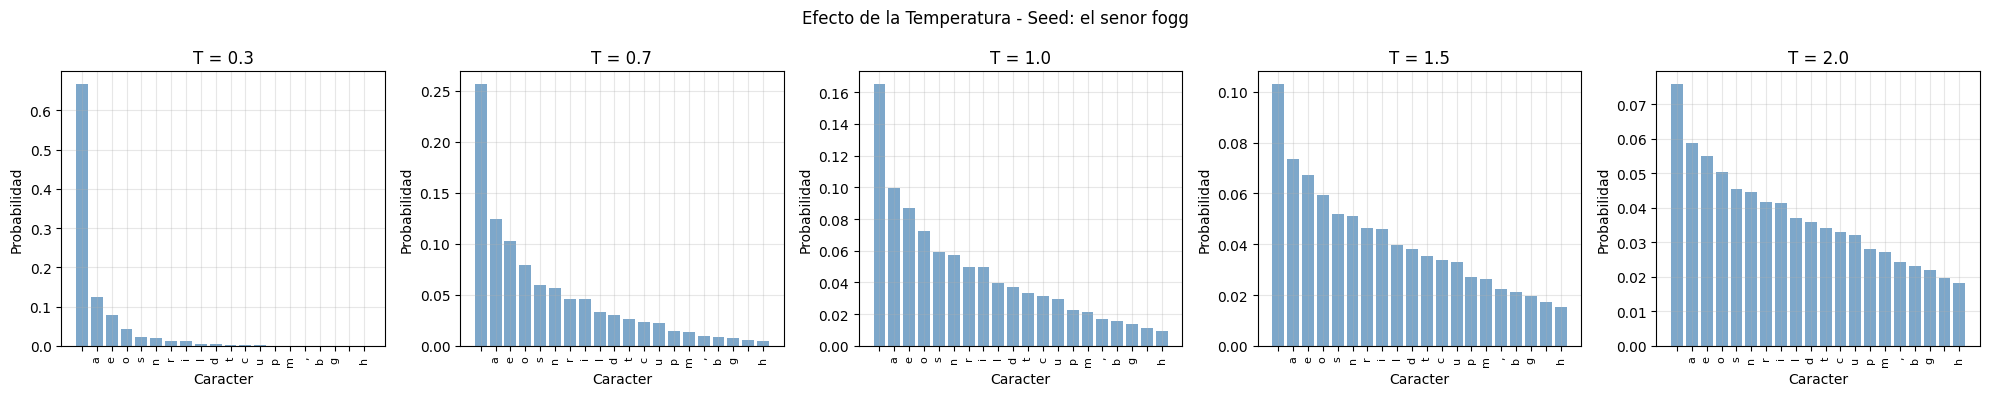

In [18]:
# Celda 16 - Visualizacion del efecto de la temperatura
probs_base = best_model.predict(encode(SEED_TEXT), verbose=0)[0, -1, :]
top_k      = 20
top_idx    = np.argsort(probs_base)[::-1][:top_k]
top_chars  = [idx2char[i] for i in top_idx]

fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))
for ax, temp in zip(axes, temperatures):
    probs_temp = softmax(np.log(probs_base + 1e-10) / temp)
    ax.bar(range(top_k), probs_temp[top_idx], color='steelblue', alpha=0.7)
    ax.set_xticks(range(top_k))
    ax.set_xticklabels([str(c) for c in top_chars], rotation=90, fontsize=8)
    ax.set_title('T = ' + str(temp))
    ax.set_xlabel('Caracter')
    ax.set_ylabel('Probabilidad')
    ax.grid(True, alpha=0.3)

plt.suptitle('Efecto de la Temperatura - Seed: ' + SEED_TEXT)
plt.tight_layout()
plt.show()

## Reporte Final

---

### 1. Corpus seleccionado

Se utilizó **"La vuelta al mundo en 80 días"** de Julio Verne, obtenido de textos.info.
Es un corpus en español de ~395K caracteres con vocabulario variado y estructura narrativa.

---

### 2. Pre-procesamiento y tokenización por caracteres

La **tokenización por caracteres** convierte cada carácter individual del texto en un índice entero.
A diferencia de la tokenización por palabras (vocabulario ~50.000), aquí el vocabulario es mínimo:

| Parámetro | Valor |
|-----------|-------|
| Caracteres únicos (vocab_size) | 67 |
| Tokens totales | 395.528 |
| Contexto (MAX_CONTEXT_SIZE) | 100 caracteres |
| Secuencias de entrenamiento (STEP=5) | ~71.000 |
| Split train/validación | 90% / 10% |

El dataset se estructuró como problema **many-to-many**: la entrada X y el target y son
la misma secuencia desplazada 1 posición, permitiendo que cada token genere una señal de gradiente.

---

### 3. Arquitecturas propuestas

Se propusieron y entrenaron tres arquitecturas con el optimizador `rmsprop` (recomendado para RNNs):

| Modelo | Parámetros |
|--------|-----------|
| SimpleRNN | ~34K | 
| LSTM | ~110K | 
| GRU | ~84K | 

Todas usan `TimeDistributed(CategoryEncoding)` para convertir índices a vectores One-Hot,
`return_sequences=True` para el esquema many-to-many, y `Dense(softmax)` para predecir
la distribución sobre el vocabulario.

---

### 4. Entrenamiento y Perplejidad

La **perplejidad** mide qué tan bien el modelo predice las secuencias de validación:


Resultados del entrenamiento (30 épocas, PATIENCE=30):

| Modelo | PPL mínima | Época | PPL época 30 |
|--------|-----------|-------|-------------|
| SimpleRNN | 20.73 | 2 | 23.04 |
| **LSTM** | **20.70** | **1** | **22.52** |
| GRU | 20.74 | 1 | 23.84 |

**Observación clave:** el loss de entrenamiento baja correctamente en los 3 modelos
(de ~3.3 a ~2.9), lo que confirma que **el modelo sí aprende**. Sin embargo,
la perplejidad de validación sube progresivamente — señal de **overfitting**:
el modelo memoriza los patrones del corpus de entrenamiento pero no generaliza
bien al 10% final del libro (conjunto de validación).

Esto se debe a que con `STEP=5` se generan ~71.000 secuencias altamente solapadas,
lo que favorece la memorización sobre la generalización.

---

### 5. Generación de secuencias

Se utilizó el mejor modelo (LSTM, PPL=20.70) para generar texto con distintas estrategias.

#### Greedy Search
Elige el carácter con mayor probabilidad en cada paso (`argmax`). 
**Resultado:** loop repetitivo de 'a' y espacios. El modelo aprendió que 'a' y ' ' son
los caracteres más frecuentes del español, pero no aprendió las transiciones contextuales.

#### Top-k Sampling (k=5, T=0.7)
Muestrea aleatoriamente entre los k caracteres más probables aplicando temperatura.
**Resultado:** evita el loop pero genera texto sin coherencia semántica,
combinaciones de letras que no forman palabras reconocibles.

#### Nucleus Sampling (p=0.9, T=0.7)
Muestrea entre los tokens que acumulan probabilidad >= p.
**Resultado:** similar al top-k, sin coherencia semántica.

#### Beam Search Determinístico (5 beams)
Mantiene las 5 hipótesis con mayor log-probabilidad acumulada.
**Resultado:** todos los beams convergen al mismo loop de 'a'.

#### Beam Search Estocástico con Temperatura
| Temperatura | Resultado |
|------------|----------|
| T=0.3 | Loop de 'a' — distribución muy concentrada |
| T=0.7 | Mezcla de letras frecuentes, sin palabras |
| T=1.0 | Más variedad, algunas combinaciones reconocibles |
| T=1.5 | Texto más creativo pero incoherente |
| T=2.0 | Casi aleatorio, palabras inventadas |

El gráfico de temperatura muestra correctamente el comportamiento esperado:
T baja → distribución concentrada en pocos caracteres;
T alta → distribución casi uniforme.


